### Lab 5: Multiple Linear Regression

#### Step-by-Step Instructions:


In [1]:
# Hello everyone! In this lab we'll walk through a multiple linear regression example using synthetic mobile application data.

import numpy as np  # Importing numpy for numerical operations
import pandas as pd  # Importing pandas for data manipulation
import matplotlib.pyplot as plt  # Importing matplotlib for plotting
from sklearn.linear_model import LinearRegression  # Importing LinearRegression from sklearn
from sklearn.metrics import mean_squared_error  # Importing mean_squared_error from sklearn
from sklearn.model_selection import train_test_split  # Importing train_test_split from sklearn
import seaborn as sns  # Importing seaborn for advanced visualizations

# Let's start by loading our dataset into a pandas DataFrame.
raw_dataset = pd.read_csv('Synthetic_app_data.csv')  # Reading the CSV file into a DataFrame

# Displaying the first 5 rows of the dataset to get an idea of what it looks like.
print(raw_dataset.head())  # Displaying the first 5 rows of the DataFrame




   Average Response Time (s)  Number of Features  Number of Bugs Reported  \
0                   1.436350                  49                       16   
1                   2.876786                  36                       12   
2                   2.329985                  34                        0   
3                   1.996646                  39                        1   
4                   0.890047                  44                        8   

   Training Hours Provided  User Satisfaction Score  
0                 3.970126                89.980978  
1                 3.100364                56.732146  
2                 2.667305               121.502856  
3                 4.469463               124.535638  
4                 3.942986               129.077397  


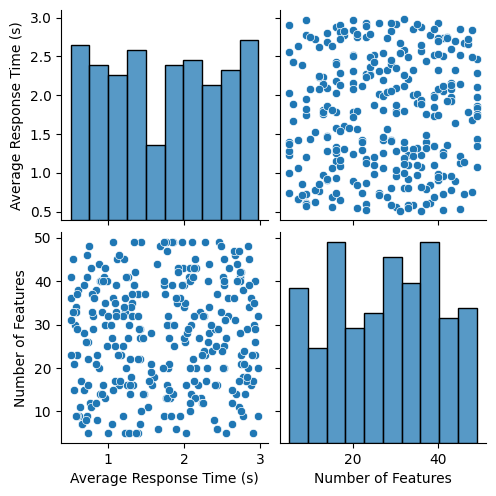

In [2]:
# Creating a pairplot to visualize the relationships between different variables.
sns.pairplot(raw_dataset[['Average Response Time (s)', 'Number of Features']])  # Pairplot to visualize the relationship between 'Average Response Time (s)' and 'Number of Features' remember it's important that we use independant variables that have linearity with the dependant variable.



In [3]:
# Printing the column names of the dataset.
print(raw_dataset.columns)  # Displaying the column names of the DataFrame

# Separating the independent variables (features) and dependent variable (target).
indp_vars = raw_dataset[['Average Response Time (s)', 'Number of Features', 'Number of Bugs Reported', 'Training Hours Provided']]  # Selecting multiple columns as independent variables
dep_var = raw_dataset['User Satisfaction Score']  # Selecting 'User Satisfaction Score' as the dependent variable

# Splitting the data into training and testing sets.
train_x, test_x, train_y, test_y = train_test_split(indp_vars, dep_var, test_size=0.2, random_state=42)  # Splitting the data with 80% for training and 20% for testing



Index(['Average Response Time (s)', 'Number of Features',
       'Number of Bugs Reported', 'Training Hours Provided',
       'User Satisfaction Score'],
      dtype='object')


In [4]:
# Creating a Linear Regression model and fitting it to the training data.
lr_model = LinearRegression()  # Creating an instance of LinearRegression
lr_model.fit(train_x, train_y)  # Fitting the model to the training data

# Using the model to predict User Satisfaction Score on the test data.
pred = lr_model.predict(test_x)  # Making predictions on the test data

# Calculating and printing the Mean Squared Error of the model's predictions.
mse = mean_squared_error(pred, test_y)  # Calculating the Mean Squared Error between predicted and actual values
print("Mean Squared Error:", mse)  # Printing the Mean Squared Error

Mean Squared Error: 21.341088894194325


## Part 1: MLR

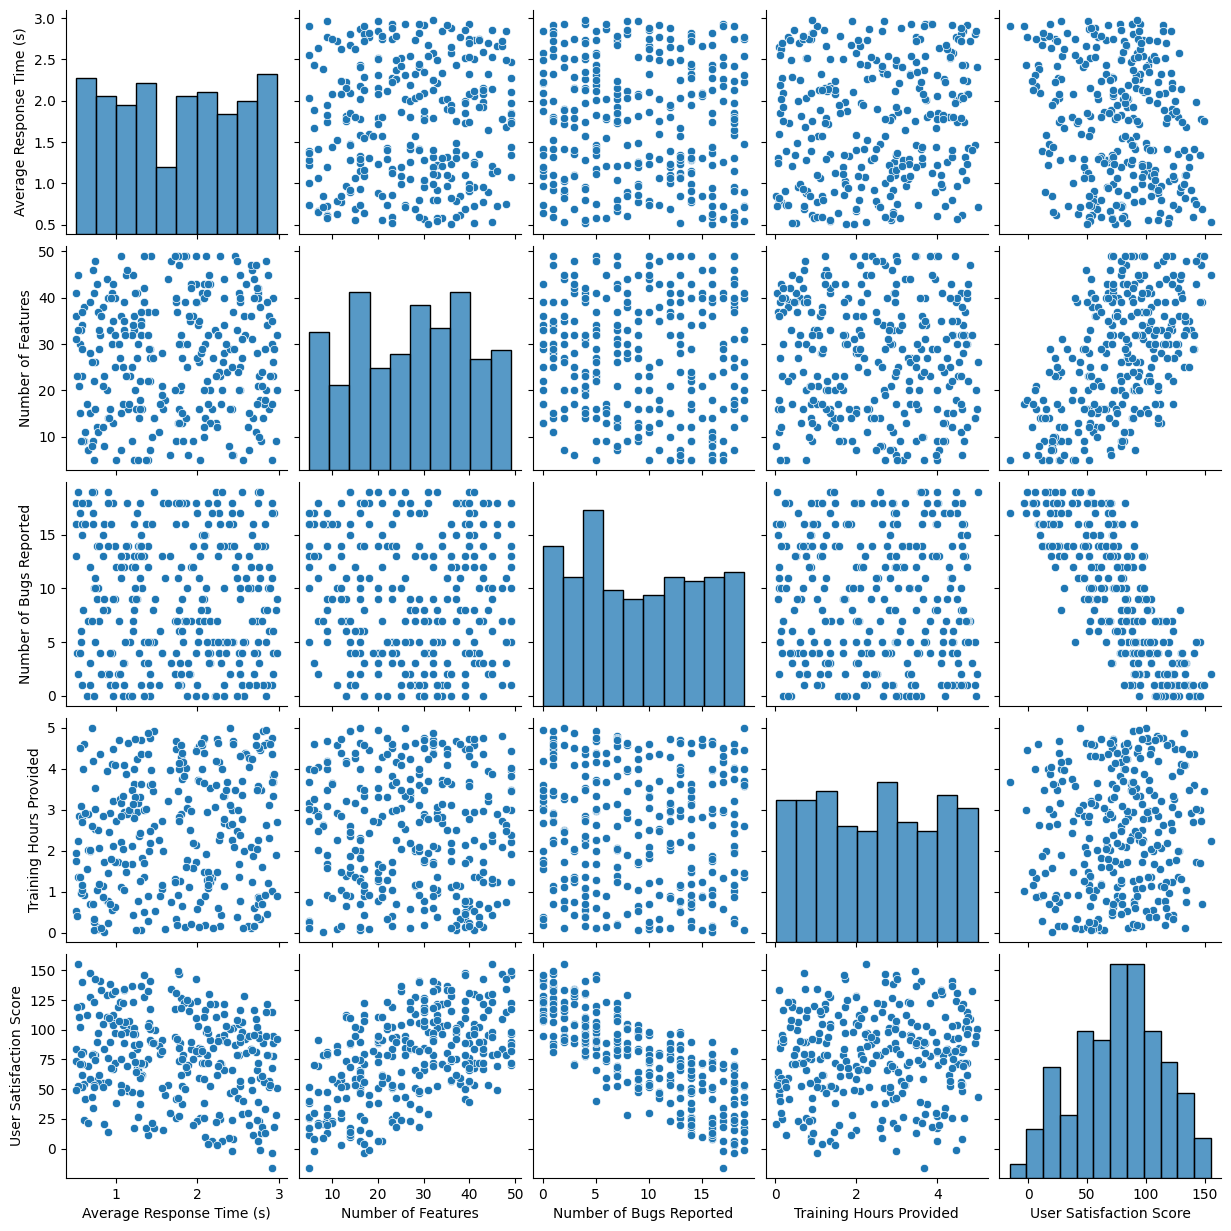

In [9]:
#Step 1/2
raw_dataset
sns.pairplot(raw_dataset)


### Observations:
- **Avg Response Time vs User Satisfaction** -> Negative correlation higher response time lower satisfaction  
- **Number of Features vs User Satisfaction** -> Slight positive trend more features may improve satisfaction  
- **Number of Bugs vs User Satisfaction** -> Strong negative correlation more bugs lower satisfaction  
- **Training Hours vs User Satisfaction** -> Moderate positive correlation more training slightly improves satisfaction  
- **Outliers** -> Some extreme values like high response time with moderate satisfaction worth investigating  
- **Key Predictors** -> Response time and bugs have the strongest impact on satisfaction  


In [10]:
#Step 4
X = raw_dataset[['Average Response Time (s)', 'Number of Features', 'Number of Bugs Reported', 'Training Hours Provided']]
y = raw_dataset['User Satisfaction Score']

# Split dataset 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")


Training Data: (240, 4), Testing Data: (60, 4)


In [11]:
#step 5
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [-14.96954945   1.50200003  -4.92889966   3.0268404 ]
Intercept: 99.04540366638571


In [16]:
#Step 6
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 21.341088894194325
R2 Score: 0.9835002165140093


## Part 2: : MLR vs LR

In [15]:
X_single = raw_dataset[['Average Response Time (s)']]
y = raw_dataset['User Satisfaction Score']

# Split dataset 80% train, 20% test
X_train_single, X_test_single, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)


slr_model = LinearRegression()
slr_model.fit(X_train_single, y_train)

y_pred_slr = slr_model.predict(X_test_single)

mse_slr = mean_squared_error(y_test, y_pred_slr)
r2_slr = r2_score(y_test, y_pred_slr)

mse_slr, r2_slr


(1166.1542277019535, 0.0983921971484133)

### MLR vs SLR Comparison

MLR  
MSE 21.34 R2 0.9835  

SLR using avg response time  
MSE 1166.15 R2 0.0984  

### Observations  
MLR way better lower MSE higher R2 explains 98 percent of variance  
SLR bad high MSE low R2 only explains 9 percent  
Response time alone bad predictor  
MLR considers all factors bugs features training hours better accuracy  

### Conclusion  
User satisfaction depends on multiple factors not just response time  
MLR better model more accurate predictions  
